<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec08_kmean_cluster_advance_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering 심화 (학생용)

이 실습에서는 K-Means 클러스터링의 심화 주제를 다룹니다:
1. **Elbow Method**: 최적의 클러스터 개수(K) 결정
2. **K-Means++**: 개선된 초기 중심점 선택 알고리즘 직접 구현
3. **DBSCAN**: 밀도 기반 클러스터링 적용 및 비교

---
**총점: 100점**

| 파트 | 내용 | 배점 |
|------|------|------|
| Part 2-1 | Elbow Method — Inertia 계산 루프 구현 | 25점 |
| Part 3-1 | K-Means++ 초기화 알고리즘 구현 | 45점 |
| Part 4-1 | DBSCAN 파라미터 설정 및 모델 생성 | 30점 |

---
**학번:** 2023042028\
**이름:** 권택주

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

---
## Part 1: 데이터셋 생성

이번 실습에서는 두 종류의 데이터셋을 사용합니다:

| 데이터셋 | 특징 | 사용 파트 |
|----------|------|-----------|
| **Blob** | 4개의 구형 클러스터, 명확한 경계 | Elbow Method, K-Means++ |
| **Moon** | 2개의 반달 형태, 비선형 경계 | K-Means vs DBSCAN 비교 |

> Moon 데이터셋은 K-Means가 잘 작동하지 않는 대표적인 예시입니다.  
> 클러스터의 형태가 구형(spherical)이 아닌 경우 K-Means는 한계를 보입니다.

---

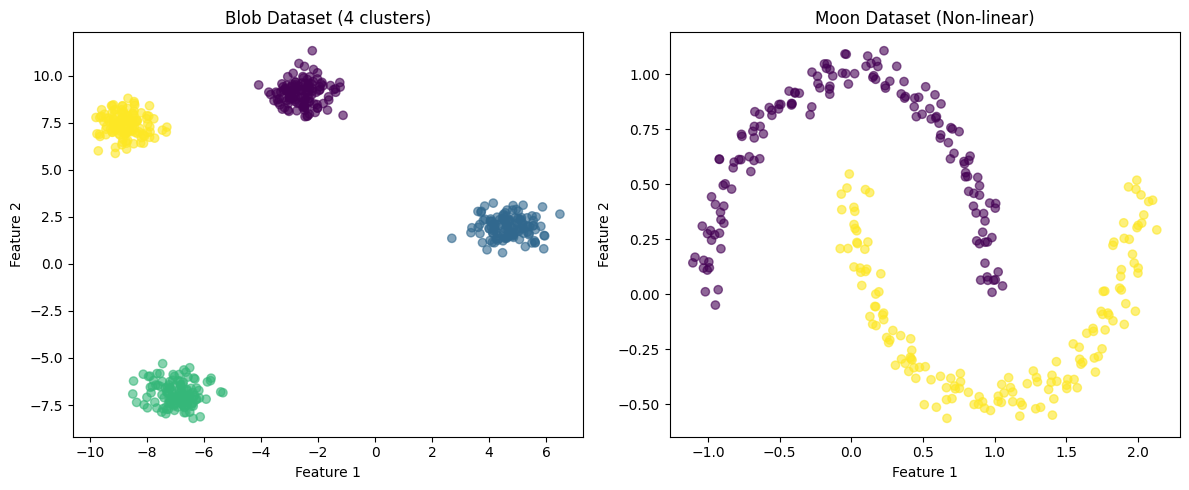

Blob 데이터: 500개 샘플
Moon 데이터: 300개 샘플


In [2]:
#@title { vertical-output: true}
# 데이터셋 1: 명확한 클러스터 (Blob)
X_blob, y_blob = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

# 데이터셋 2: 비선형 클러스터 (Moon)
X_moon, y_moon = make_moons(n_samples=300, noise=0.05, random_state=42)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='viridis', alpha=0.6)
axes[0].set_title('Blob Dataset (4 clusters)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='viridis', alpha=0.6)
axes[1].set_title('Moon Dataset (Non-linear)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"Blob 데이터: {X_blob.shape[0]}개 샘플")
print(f"Moon 데이터: {X_moon.shape[0]}개 샘플")

---
## Part 2: Elbow Method (25점)

### Elbow Method란?

K-Means에서 클러스터 개수 K는 **사전에 지정**해야 합니다.  
Elbow Method는 다양한 K 값에 대해 **Inertia(WCSS)** 를 계산하여 최적의 K를 찾는 방법입니다.

### Inertia (WCSS: Within-Cluster Sum of Squares)

각 클러스터 내에서 데이터 포인트와 중심점 간의 거리 제곱 합:

$$\text{Inertia} = \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \mu_k\|^2$$

- $K$: 클러스터 개수
- $C_k$: $k$번째 클러스터에 속한 데이터 집합
- $\mu_k$: $k$번째 클러스터의 중심점

### 해석 방법

- K가 증가하면 Inertia는 항상 감소합니다 (K = 데이터 수이면 Inertia = 0)
- **Elbow Point**: Inertia 감소율이 급격히 줄어드는 지점 → 최적 K

```
Inertia
  |
  |\          ← 급격히 감소
  | \
  |  \
  |   \___    ← 완만하게 감소
  |        \___________________
  +--------------------------- K
         ↑
    Elbow Point (최적 K)
```

### sklearn 사용법
```python
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)
kmeans.inertia_   # 학습 후 Inertia 값
```

---

### 문제 2-1. Elbow Method 구현 [25점]

**문제:** K=1부터 K=10까지 각각 KMeans를 학습시키고, Inertia 값을 `inertias` 리스트에 저장하세요.

**조건:**
- `K_range = range(1, 11)`
- `random_state=42`, `n_init=10`

**예상 결과:**
```
K=1: Inertia = 33140.86
K=2: Inertia = 15111.20
K=3: Inertia =  2899.96
K=4: Inertia =   341.60   ← Elbow Point
K=5: Inertia =   308.51
...
```

In [3]:
#@title { vertical-output: true}
K_range = range(1, 11)
inertias = []

for k in K_range:
    # IMPLEMENT HERE
    # 1. KMeans 모델 생성 (n_clusters=k, random_state=42, n_init=10)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # 2. X_blob으로 학습
    kmeans.fit(X_blob)
    # 3. inertias 리스트에 inertia 값 추가
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")
    pass

K=1: Inertia = 33140.86
K=2: Inertia = 15111.20
K=3: Inertia = 2899.96
K=4: Inertia = 341.60
K=5: Inertia = 308.51
K=6: Inertia = 277.05
K=7: Inertia = 247.28
K=8: Inertia = 215.66
K=9: Inertia = 197.32
K=10: Inertia = 178.82


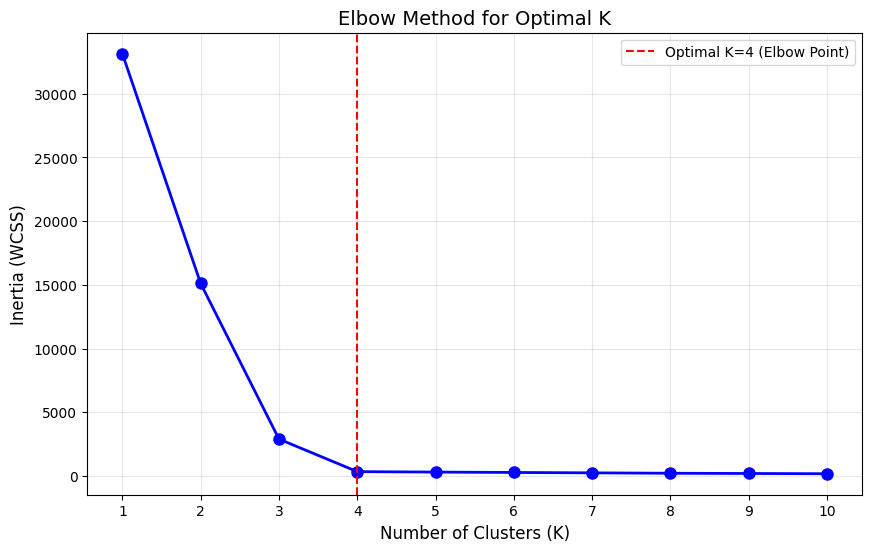


=> 그래프에서 Elbow Point(꺾이는 지점)가 최적 K입니다.


In [4]:
#@title { vertical-output: true}
# Elbow 그래프 시각화 (구현 완료 후 실행)
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='r', linestyle='--', label='Optimal K=4 (Elbow Point)')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

print("\n=> 그래프에서 Elbow Point(꺾이는 지점)가 최적 K입니다.")

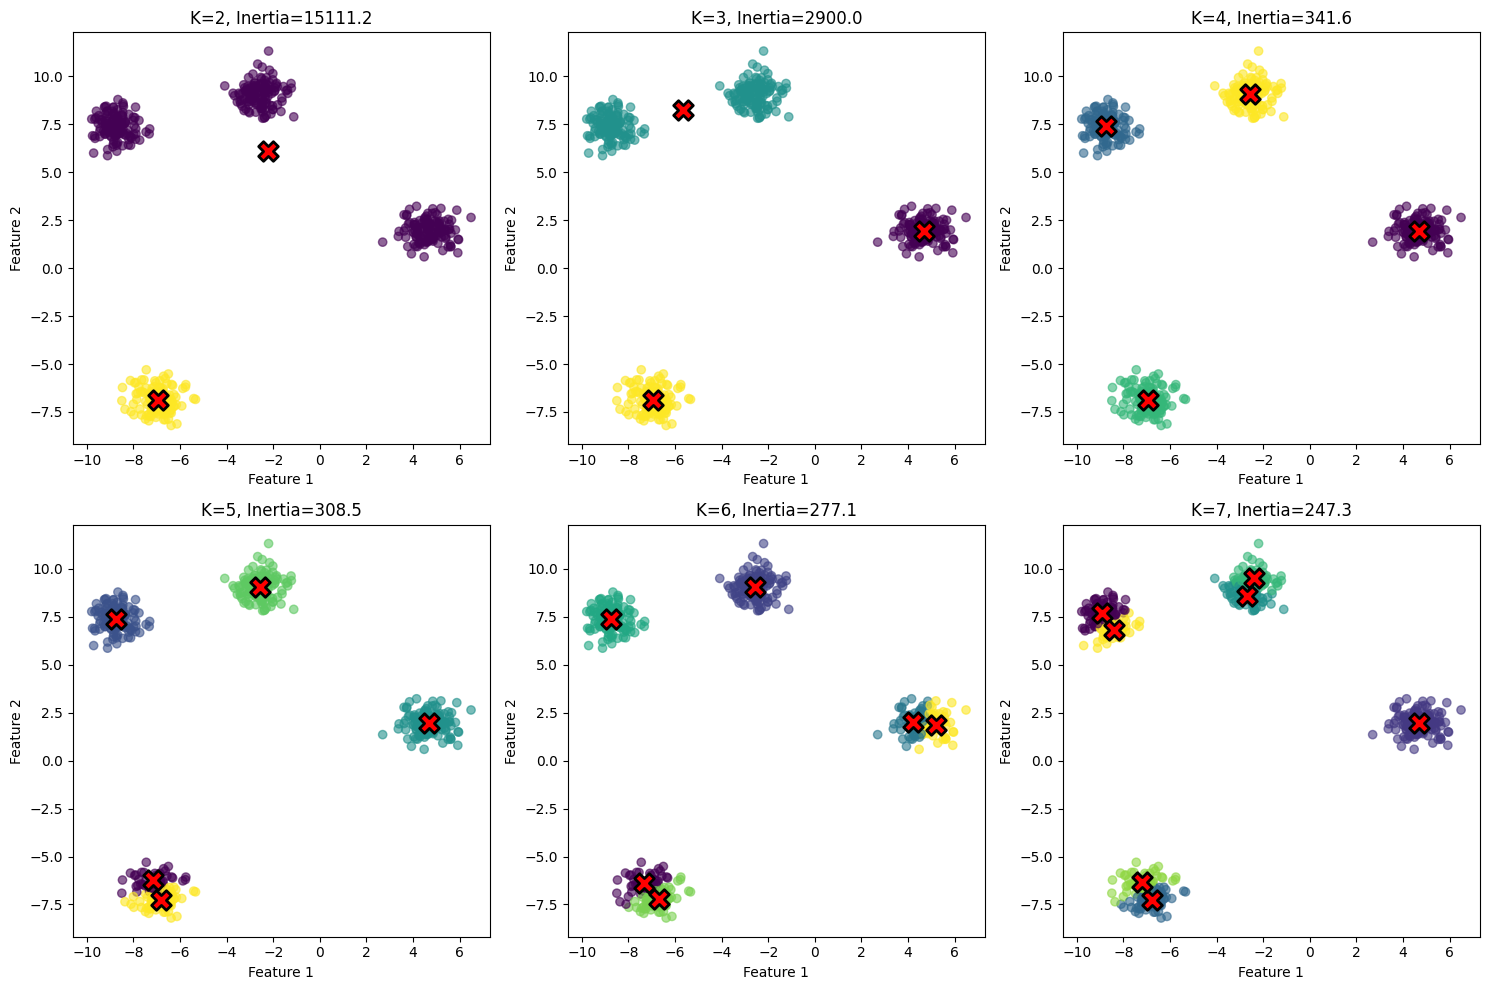

In [5]:
#@title { vertical-output: true}
# 다양한 K 값에 대한 클러스터링 결과 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, k in enumerate([2, 3, 4, 5, 6, 7]):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X_blob)

    axes[idx].scatter(X_blob[:, 0], X_blob[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
    axes[idx].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                      c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    axes[idx].set_title(f'K={k}, Inertia={kmeans.inertia_:.1f}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

---
## Part 3: K-Means++ 구현 (45점)

### 기존 K-Means의 문제점

초기 중심점을 **완전히 랜덤**하게 선택하면:
- 중심점들이 한 곳에 몰릴 수 있음
- 지역 최적해(Local Optimum)에 빠질 수 있음
- 실행마다 결과가 크게 달라질 수 있음 (불안정)

### K-Means++ 알고리즘

초기 중심점을 **서로 멀리 떨어지도록** 확률적으로 선택합니다.

**알고리즘:**

```
① 첫 번째 중심점 c₁을 데이터에서 균등하게 랜덤 선택
② for j = 2, 3, ..., K:
      ③ 각 데이터 포인트 x에 대해 가장 가까운 기존 중심점까지의
         거리 제곱 D(x)² 계산
      ④ D(x)²에 비례하는 확률로 다음 중심점 선택
         (멀리 있는 점이 선택될 확률이 높음)
```

### 확률 계산 수식

각 데이터 포인트 $x$가 다음 중심점으로 선택될 확률:

$$P(x) = \frac{D(x)^2}{\sum_{x'} D(x')^2}$$

여기서 $D(x) = \min_{c \in \text{centers}} \|x - c\|$는 $x$에서 **가장 가까운** 기존 중심점까지의 거리입니다.

### 핵심 아이디어

| 상황 | 선택 확률 |
|------|----------|
| 기존 중심점과 매우 가까운 점 | **낮음** (이미 커버되고 있음) |
| 기존 중심점과 매우 먼 점 | **높음** (새로운 영역 커버 필요) |


In [6]:
#@title { vertical-output: true}
# K-Means++ vs Random 초기화 비교 (제공)
np.random.seed(42)

n_runs = 10
random_inertias = []
plusplus_inertias = []

for i in range(n_runs):
    kmeans_random = KMeans(n_clusters=4, init='random', n_init=1, random_state=i)
    kmeans_random.fit(X_blob)
    random_inertias.append(kmeans_random.inertia_)

    kmeans_plusplus = KMeans(n_clusters=4, init='k-means++', n_init=1, random_state=i)
    kmeans_plusplus.fit(X_blob)
    plusplus_inertias.append(kmeans_plusplus.inertia_)

print("=" * 50)
print("Random vs K-Means++ 초기화 비교")
print("=" * 50)
print(f"Random    - Mean Inertia: {np.mean(random_inertias):.2f}, Std: {np.std(random_inertias):.2f}")
print(f"K-Means++ - Mean Inertia: {np.mean(plusplus_inertias):.2f}, Std: {np.std(plusplus_inertias):.2f}")
print("\n=> K-Means++가 더 안정적이고 낮은 Inertia를 달성합니다.")

Random vs K-Means++ 초기화 비교
Random    - Mean Inertia: 1352.26, Std: 1237.81
K-Means++ - Mean Inertia: 341.60, Std: 0.00

=> K-Means++가 더 안정적이고 낮은 Inertia를 달성합니다.


/tmp/ipykernel_578/92955806.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([random_inertias, plusplus_inertias], labels=['Random', 'K-Means++'])


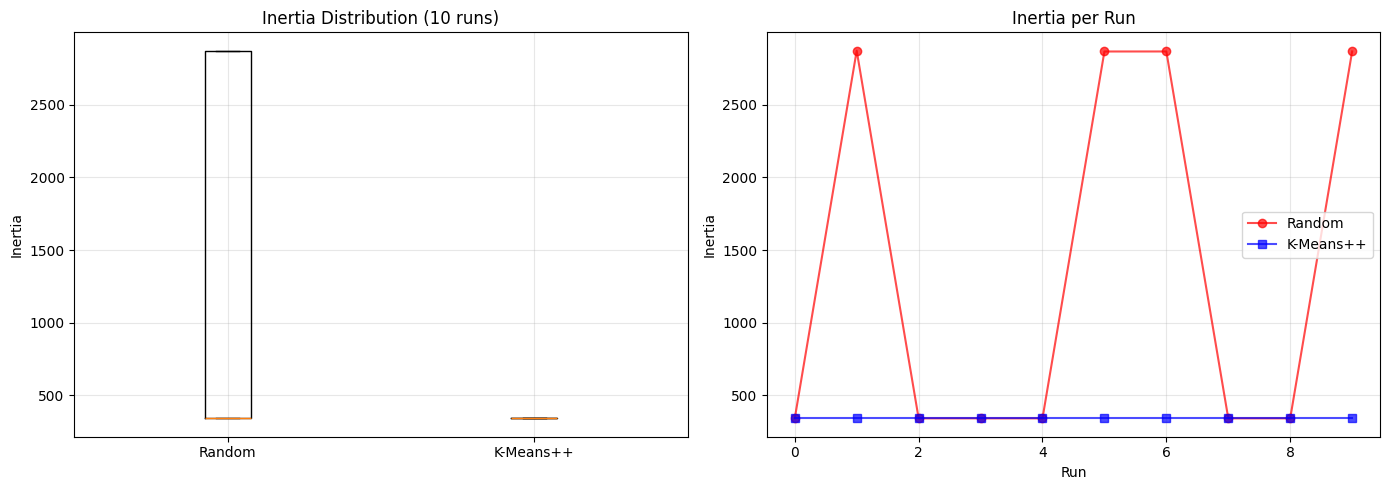

In [7]:
#@title { vertical-output: true}
# Inertia 분포 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([random_inertias, plusplus_inertias], labels=['Random', 'K-Means++'])
axes[0].set_ylabel('Inertia')
axes[0].set_title('Inertia Distribution (10 runs)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(n_runs), random_inertias, 'ro-', label='Random', alpha=0.7)
axes[1].plot(range(n_runs), plusplus_inertias, 'bs-', label='K-Means++', alpha=0.7)
axes[1].set_xlabel('Run')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Inertia per Run')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 문제 3-1. K-Means++ 초기화 함수 구현 [45점]

**문제:** K-Means++ 알고리즘을 직접 구현하세요.  
첫 번째 중심점 선택 코드는 제공됩니다. **나머지 중심점 선택 루프**를 완성하세요.

**구현 순서 (루프 내부):**
1. 모든 데이터 포인트에 대해 **가장 가까운 기존 중심점까지의 거리 제곱** 계산
2. 거리 제곱의 합으로 나눠 **확률** 계산
3. 확률에 따라 **다음 중심점 인덱스** 선택
4. 해당 데이터 포인트를 `centers`에 추가

**예상 결과:**
```
초기 중심점 4개가 데이터 전체에 고르게 분산되어 선택됩니다.
```

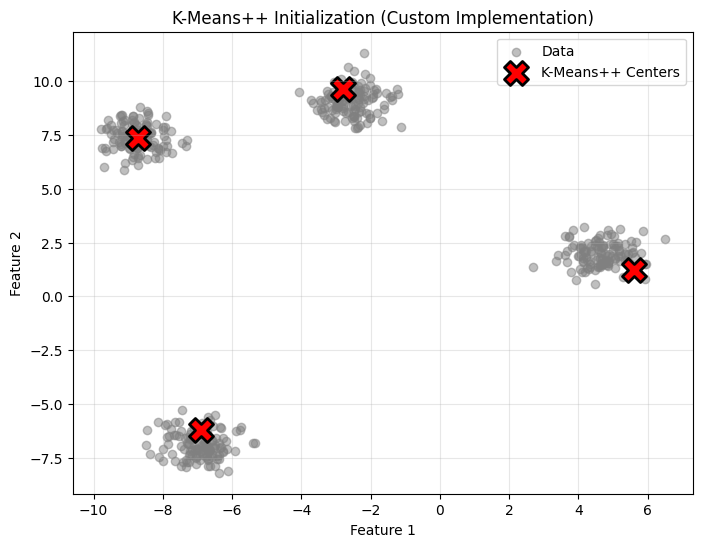

초기 중심점:
  Center 1: (5.59, 1.23)
  Center 2: (-6.90, -6.22)
  Center 3: (-8.72, 7.35)
  Center 4: (-2.79, 9.65)


In [9]:
#@title { vertical-output: true}
def kmeans_plusplus_init(X, n_clusters, random_state=42):
    """
    K-Means++ 초기화 알고리즘

    Parameters:
    - X: 데이터 (n_samples, n_features)
    - n_clusters: 클러스터 개수
    - random_state: 랜덤 시드

    Returns:
    - centers: 초기 중심점 (n_clusters, n_features)
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]
    centers = []

    # Step 1: 첫 번째 중심점을 랜덤하게 선택 (제공)
    first_idx = np.random.randint(n_samples)
    centers.append(X[first_idx])

    # IMPLEMENT HERE: 나머지 중심점 선택 (Step 2~4 반복)
    for _ in range(1, n_clusters):
        # 1. 각 점에서 가장 가까운 중심점까지의 거리 제곱 계산
        distances = np.array([
            min(np.sum((x - c) ** 2) for c in centers)
            for x in X
        ])

        # 2. D(x)^2에 비례하는 확률 계산
        probabilities = distances / distances.sum()

        # 3. 확률에 따라 다음 중심점 선택
        next_idx = np.random.choice(n_samples, p=probabilities)
        centers.append(X[next_idx])

    return np.array(centers)

# 구현 후 테스트
custom_centers = kmeans_plusplus_init(X_blob, n_clusters=4)

plt.figure(figsize=(8, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c='gray', alpha=0.5, label='Data')
plt.scatter(custom_centers[:, 0], custom_centers[:, 1],
            c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='K-Means++ Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means++ Initialization (Custom Implementation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("초기 중심점:")
for i, c in enumerate(custom_centers):
    print(f"  Center {i+1}: ({c[0]:.2f}, {c[1]:.2f})")

---
## Part 4: DBSCAN (30점)

### DBSCAN이란?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)은 **밀도 기반** 클러스터링 알고리즘입니다.

### K-Means vs DBSCAN 비교

| 특성 | K-Means | DBSCAN |
|------|---------|--------|
| 클러스터 개수 | **사전 지정 필요** | **자동 결정** |
| 클러스터 형태 | 구형(Spherical)만 | **임의의 형태** 가능 |
| 이상치 처리 | 없음 (모든 점이 클러스터에 포함) | **노이즈로 자동 분류** |
| 비선형 경계 | 처리 어려움 | **처리 가능** |

### 주요 파라미터

**`eps` (ε):** 이웃을 정의하는 반경
- 같은 클러스터로 간주할 두 점 사이의 최대 거리
- 너무 작으면: 모든 점이 노이즈가 됨
- 너무 크면: 모든 점이 하나의 클러스터

**`min_samples`:** Core point가 되기 위한 최소 이웃 수
- eps 반경 내에 min_samples개 이상의 점이 있어야 Core point
- 크면 더 엄격한 기준 → 더 많은 노이즈

### 점의 분류

```
● Core Point   : eps 반경 내 min_samples개 이상의 점이 있는 점
○ Border Point : Core point는 아니지만 Core point의 이웃인 점
✕ Noise Point  : Core point도 Border point도 아닌 점 (레이블 = -1)
```

### sklearn 사용법

```python
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)   # 노이즈는 -1로 표시

# 클러스터 개수 (노이즈 제외)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
```

> **중요:** DBSCAN은 거리 기반이므로 `StandardScaler`로 **스케일링 후** 적용해야 합니다.

---

### 문제 4-1. DBSCAN 파라미터 설정 및 모델 생성 [30점]

**문제:** Moon 데이터셋에 DBSCAN을 적용하여 K-Means와 비교하세요.

**조건:**
- `X_moon_scaled` (StandardScaler 적용된 데이터)를 사용하세요.
- Moon 데이터의 2개 클러스터가 정확히 분리되도록 `eps`와 `min_samples`를 설정하세요.

**파라미터 선택 가이드:**
- Moon 데이터는 밀도가 높고 노이즈가 적은 데이터입니다.
- `eps`: 스케일링된 데이터 기준, 0.2~0.5 범위에서 시도
- `min_samples`: 5 내외

**예상 결과:**
```
DBSCAN 클러스터 개수: 2
DBSCAN 노이즈 포인트: 0개
```
그리고 Moon 형태의 2개 클러스터가 정확히 분리되어 시각화됩니다.

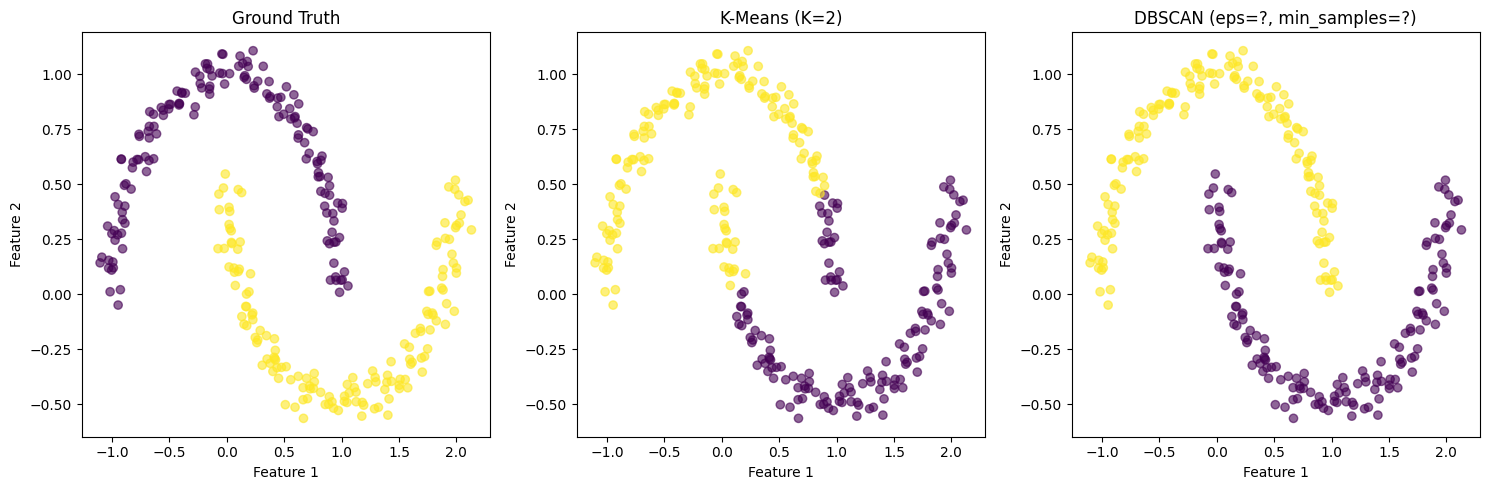

DBSCAN 클러스터 개수: 2
DBSCAN 노이즈 포인트: 0개


In [ ]:
#@title { vertical-output: true}
# 데이터 스케일링 (제공)
scaler = StandardScaler()
X_moon_scaled = scaler.fit_transform(X_moon)

# K-Means 클러스터링 (제공)
kmeans_moon = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans_moon.fit_predict(X_moon_scaled)

# IMPLEMENT HERE: DBSCAN 모델 생성 및 학습
dbscan_moon = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan_moon.fit_predict(X_moon_scaled)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 원본 데이터 (Ground Truth)
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='viridis', alpha=0.6)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Means 결과
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_kmeans, cmap='viridis', alpha=0.6)
axes[1].set_title('K-Means (K=2)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# DBSCAN 결과
colors = ['gray' if label == -1 else plt.cm.viridis(label / max(y_dbscan.max(), 1)) for label in y_dbscan]
axes[2].scatter(X_moon[:, 0], X_moon[:, 1], c=colors, alpha=0.6)
axes[2].set_title(f'DBSCAN (eps=?, min_samples=?)')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"DBSCAN 클러스터 개수: {len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)}")
print(f"DBSCAN 노이즈 포인트: {np.sum(y_dbscan == -1)}개")

---
## 제출 안내

### 제출 파일
1. **`.ipynb` 파일**: 모든 셀을 실행한 상태로 저장
2. **`.pdf` 파일**: 파일 → 인쇄 → PDF로 저장

### 파일명
```
kmean_cluster_advance_[학번]_[이름].ipynb
kmean_cluster_advance_[학번]_[이름].pdf
```

### 제출 체크리스트
- [ ] Part 2-1: Inertia 루프 구현 완료 및 Elbow 그래프 확인
- [ ] Part 3-1: `kmeans_plusplus_init` 구현 완료 및 시각화 확인
- [ ] Part 4-1: DBSCAN 파라미터 설정 완료, 클러스터 2개 분리 확인
- [ ] `.ipynb`와 `.pdf` 모두 제출

### LMS 제출
두 파일을 **기한 내에** LMS에 제출하세요.  
> ⚠️ **기한 내에 제출하지 않으면 감점이 있습니다.**

---